# Build results

Build success, compiler errors/warnings and convergence behavior per model, from `BuildResults/`. *Final run* = last execution of an iteration; *all attempts* includes every retry.

In [1]:
STORY_ID = "CPD-LC-001-005"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import tdd_results as tdd

tdd.setup_theme()
# Clear the per-session label cache and warning list first: re-running this
# cell after dropping new results into the trees would otherwise reuse stale
# model labels and count the same load warning once per re-run.
tdd.reset_caches()
data = tdd.load_all(STORY_ID)
MODELS = tdd.discover_models(STORY_ID)
if not MODELS:
    print(f"no results found for {STORY_ID!r}; stories present in the result "
          f"trees: {tdd.discover_stories()}")
PAL = tdd.model_palette(MODELS)        # fixed model -> color, used everywhere
HUE = list(PAL)                        # fixed hue_order, used everywhere

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print(f"story: {STORY_ID} | models: {MODELS}")
print("palette:", PAL)
if tdd.load_warnings:
    print(f"{len(tdd.load_warnings)} load warnings -> tdd.load_warnings")

story: CPD-LC-001-005 | models: ['Kimi-K2.5', 'Qwen3.7-max']
palette: {'Kimi-K2.5': '#2a78d6', 'Qwen3.7-max': '#1baf7a'}


## Data integrity gate

Identity drift, evidence and metric signal, checked before the charts.


In [3]:
summ = tdd.iteration_summary(STORY_ID, data)
sig = tdd.discrimination(summ)
drift = tdd.audit_identity(STORY_ID)
dead = sig[sig["status"].isin(["ABSENT", "ALL-NA", "CONSTANT"])]
print(f"identity : {len(drift)} disagreements, "
      f"{(~drift['reconciles']).sum() if not drift.empty else 0} unreconcilable")
print(f"signal   : {len(sig) - len(dead)}/{len(sig)} metrics discriminate")
if not dead.empty:
    display(dead)


identity : 65 disagreements, 0 unreconcilable
signal   : 19/24 metrics discriminate


,metric,family,provenance,status,distinct,na_share
9,red_first,C convergence,tool-measured,CONSTANT,1,0.0
11,evidence_completeness,E evidence,derived,CONSTANT,1,0.0
16,ref_all_green,Q quality,self-reported,CONSTANT,1,0.0
19,layer_balance,V verification,tool-measured,CONSTANT,1,0.0
20,layer_coverage,V verification,tool-measured,CONSTANT,1,0.0


## Build success: final run vs all attempts

The *final run* bar is where the agent left the iteration; the *all attempts*
bar includes every retry. A large gap means the model reached a working build
by brute force rather than at the first try.

**Chart columns** — `model` (x); `build success rate` (y) — share of build executions with status `success`; bar pair — scope: **final run** (dark; one execution per iteration, where it ended) vs **all attempts** (light; every execution, the road there).

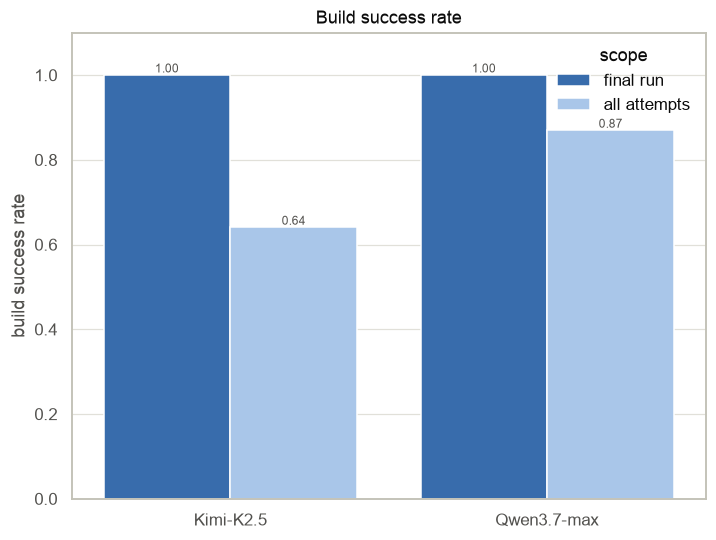

In [4]:
b = data["build"]
if b.empty:
    print("No build data.")
else:
    rates = pd.concat([
        tdd.finals(b).assign(scope="final run"),
        b.assign(scope="all attempts"),
    ])
    rates = (rates.assign(is_success=rates["status"].eq("success"))
                  .groupby(["model", "scope"], as_index=False)["is_success"].mean())
    ax = sns.barplot(data=rates, x="model", y="is_success", hue="scope",
                     order=HUE, hue_order=["final run", "all attempts"],
                     palette={"final run": "#256abf", "all attempts": "#9ec5f4"})
    tdd.label_bars(ax, fmt="%.2f")
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("build success rate")
    ax.set_xlabel("")
    ax.set_title("Build success rate")

## Final build status per (model, iteration)

Green = final build succeeded, red = iteration ended broken. Numbers are
the error count of the final build.

**Chart columns** — rows — model; columns — `iteration` (run 1–6); cell color — final build `status` (green = success, red = failure); cell number — `total_errors`, compiler errors of that final build (0 on green cells).

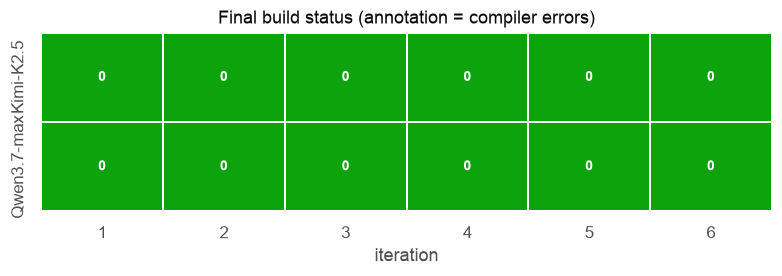

In [5]:
from matplotlib.colors import BoundaryNorm, ListedColormap

fin = tdd.finals(data["build"])
if fin.empty:
    print("No build data.")
else:
    status = (fin.pivot(index="model", columns="iteration", values="status")
                 .reindex(index=HUE))
    errors = (fin.pivot(index="model", columns="iteration", values="total_errors")
                 .reindex(index=HUE))
    cmap = ListedColormap([tdd.STATUS_COLORS["RED"], tdd.STATUS_COLORS["GREEN"]])
    norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)
    annot = errors.map(lambda v: "" if pd.isna(v) else f"{int(v)}")
    fig, ax = plt.subplots(figsize=(7, 2.4))
    sns.heatmap(status.map({"success": 1, "failure": 0}.get), cmap=cmap, norm=norm,
                cbar=False, annot=annot, fmt="", linewidths=1, linecolor="white",
                annot_kws={"fontsize": 9, "color": "white", "fontweight": "bold"}, ax=ax)
    ax.set_facecolor("#f0efec")
    ax.set_ylabel("")
    ax.set_title("Final build status (annotation = compiler errors)")

## Error and warning distributions (all attempts)

Every build execution counts here — this is what the agent fought through.

**Chart columns** — `model` (x); y — `total_errors` (left) / `total_warnings` (right) of each build execution, all attempts pooled; box — median/IQR; dots — executions (axis switches to symlog when values exceed 50).

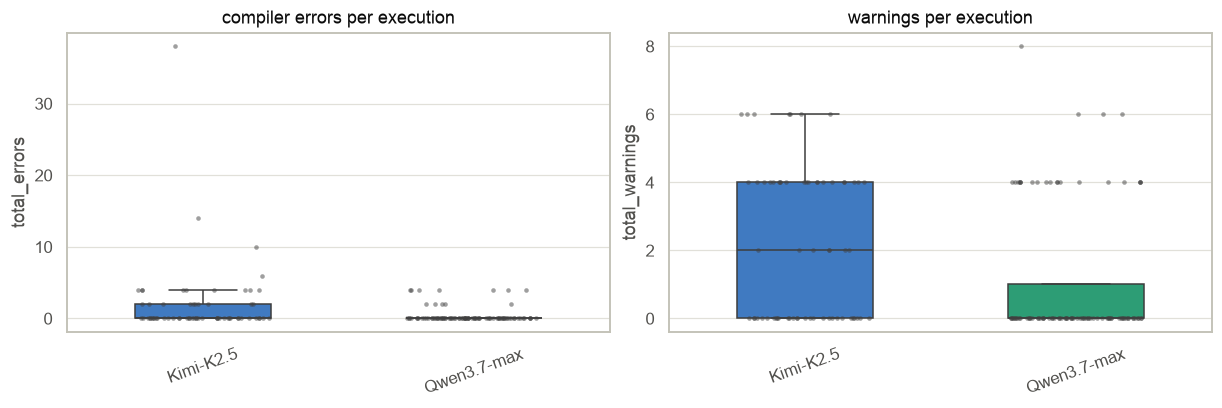

In [6]:
if b.empty:
    print("No build data.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    for ax, col, name in [(axes[0], "total_errors", "compiler errors"),
                          (axes[1], "total_warnings", "warnings")]:
        sns.boxplot(data=b, x="model", y=col, hue="model", order=HUE,
                    hue_order=HUE, palette=PAL, legend=False, width=0.5,
                    showfliers=False, ax=ax)
        sns.stripplot(data=b, x="model", y=col, order=HUE, color=".25",
                      size=3, alpha=0.5, jitter=0.25, ax=ax)
        if b[col].max() > 50:
            ax.set_yscale("symlog", linthresh=10)
        ax.set_title(f"{name} per execution")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)

## Error burn-down across attempts

Per iteration: compiler errors at each successive execution. Lines that fall
to zero and stay there converged; sawtooth lines are churn.

**Chart columns** — one panel per `iteration`: `attempt #` (x) — chronological rank of the build execution within the run; `compiler errors` (y) — `total_errors` at that attempt; line color — model.

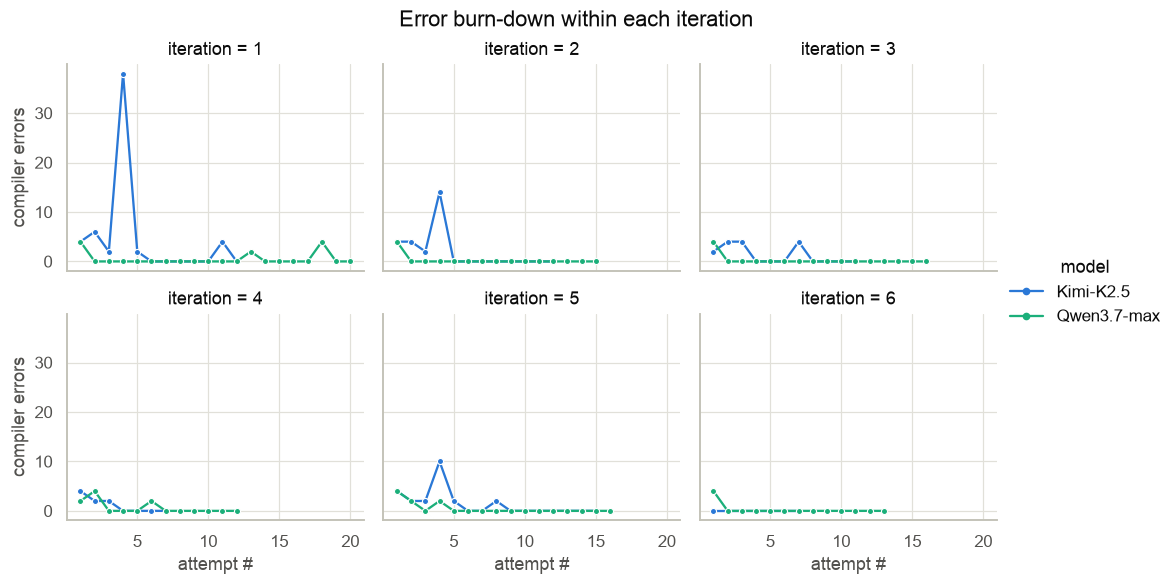

In [7]:
if b.empty:
    print("No build data.")
else:
    g = sns.relplot(data=b, kind="line", x="attempt", y="total_errors",
                    hue="model", col="iteration", col_wrap=3, hue_order=HUE,
                    palette=PAL, estimator=None, marker="o", markersize=4,
                    height=2.6, aspect=1.2)
    g.set_axis_labels("attempt #", "compiler errors")
    g.figure.suptitle("Error burn-down within each iteration", y=1.02)

## Convergence cost per run

The headline "did it build?" cannot separate models: the pipeline does not
stop until the build compiles, so the final status is `success` for every run
by construction. What differs is the cost of getting there, and that is what
this section scores.

**Chart & table columns** — left: `failed executions` per run (bar) — build
executions that did not compile; right: `errors burned` (bar, log scale) —
compiler errors fought through in total, with `peak errors` (marker) — the
worst single execution, which separates a long grind from one blow-up.
Table: those three plus `build_execs` (all executions) and `build_first_pass`
(compiled on the very first try).


,model,iteration,build_execs,build_failed_execs,build_errors_burned,build_peak_errors,build_first_pass
0,Kimi-K2.5,1,12,6,56,38,False
1,Kimi-K2.5,2,12,4,24,14,False
2,Kimi-K2.5,3,11,4,14,4,False
3,Kimi-K2.5,4,7,3,8,4,False
4,Kimi-K2.5,5,15,6,22,10,False
5,Kimi-K2.5,6,7,0,0,0,True
6,Qwen3.7-max,1,20,3,10,4,False
7,Qwen3.7-max,2,15,1,4,4,False
8,Qwen3.7-max,3,16,1,4,4,False
9,Qwen3.7-max,4,12,3,8,4,False


hardest run: Kimi-K2.5 it 1 — 56 errors across 12 executions


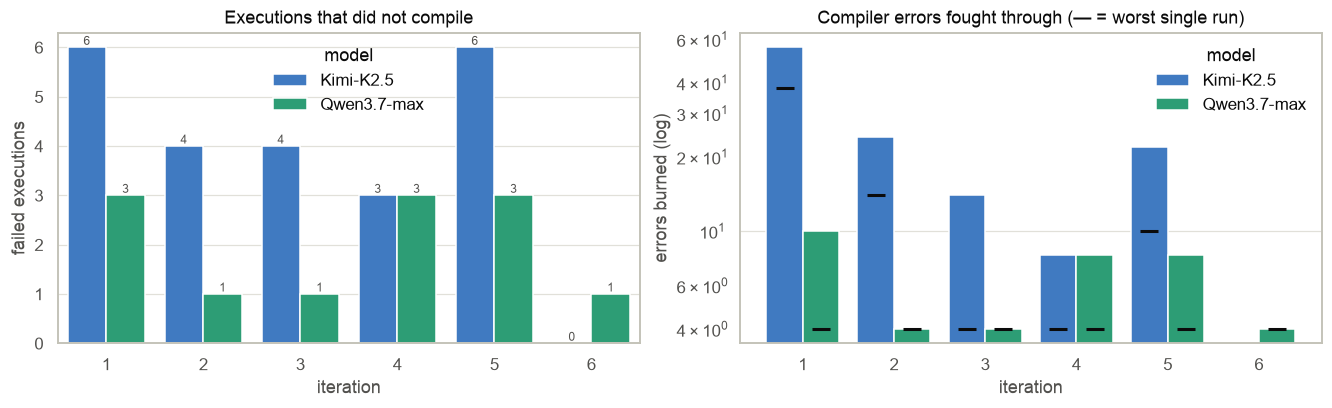

In [8]:
conv = summ[["model", "iteration", "build_execs", "build_failed_execs",
           "build_errors_burned", "build_peak_errors", "build_first_pass"]].copy()
if conv.empty or conv["build_execs"].isna().all():
    print("No build data for this section.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
    sns.barplot(data=conv, x="iteration", y="build_failed_execs", hue="model",
                hue_order=HUE, palette=PAL, errorbar=None, ax=axes[0])
    axes[0].set_ylabel("failed executions")
    axes[0].set_title("Executions that did not compile")
    tdd.label_bars(axes[0], fmt="%.0f")

    sns.barplot(data=conv, x="iteration", y="build_errors_burned", hue="model",
                hue_order=HUE, palette=PAL, errorbar=None, ax=axes[1])
    for model, g in conv.groupby("model"):
        offset = -0.2 if model == HUE[0] else 0.2
        axes[1].scatter(g["iteration"] - 1 + offset, g["build_peak_errors"],
                        marker="_", s=140, linewidths=2,
                        color=tdd.INK["primary"], zorder=5)
    axes[1].set_yscale("log")
    axes[1].set_ylabel("errors burned (log)")
    axes[1].set_title("Compiler errors fought through (— = worst single run)")
    axes[1].legend(title="model")

    display(conv.sort_values(["model", "iteration"]).reset_index(drop=True))
    worst = conv.loc[conv["build_errors_burned"].idxmax()]
    print(f"hardest run: {worst['model']} it {worst['iteration']} — "
          f"{worst['build_errors_burned']:.0f} errors across "
          f"{worst['build_execs']:.0f} executions")


## Which projects fail to build

Failed project × model counts across all attempts — shows whether models
trip over the same parts of the architecture.

**Chart columns** — `project` (y) — solution project that failed to compile (shared name prefix stripped), sorted by failure count; `failed build executions` (x) — executions (all attempts) in which it failed; bar color — model.

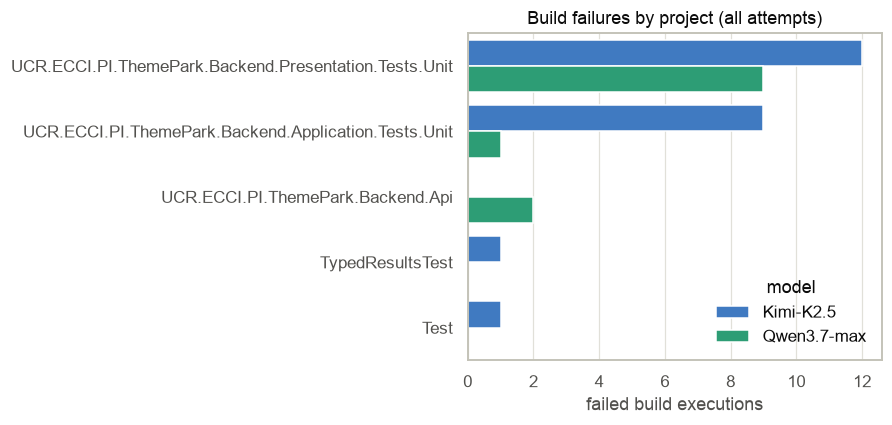

In [9]:
import os

bp = data["build_projects"]
failed = bp[bp["status"] != "success"].copy() if not bp.empty else bp
if failed.empty:
    print("No failing projects recorded.")
else:
    prefix = os.path.commonprefix(list(failed["project"].unique()))
    prefix = prefix[: prefix.rfind(".") + 1] if "." in prefix else ""
    failed["project_short"] = failed["project"].str.removeprefix(prefix)
    order = failed["project_short"].value_counts().index
    fig, ax = plt.subplots(figsize=(8, 0.45 * len(order) + 1.5))
    sns.countplot(data=failed, y="project_short", hue="model", order=order,
                  hue_order=HUE, palette=PAL, ax=ax)
    ax.set_ylabel("")
    ax.set_xlabel("failed build executions")
    ax.set_title("Build failures by project (all attempts)")

## Sanity checks

In [10]:
if not b.empty:
    fb = tdd.finals(b)
    assert fb.groupby(["story", "model", "iteration"]).size().max() == 1
    assert (b["total_errors"] >= 0).all()
assert summ["model"].isin(HUE).all(), "identity drift leaked into the master table"
assert drift.empty or drift["reconciles"].all(), "misfiled results present"
if not conv.empty:
    assert (conv["build_failed_execs"] <= conv["build_execs"]).all(), \
        "failed executions cannot exceed total executions"
    assert (conv["build_peak_errors"] <= conv["build_errors_burned"]).all(), \
        "peak errors cannot exceed the total burned"
print(f"sanity checks passed | {len(tdd.load_warnings)} load warnings | "
      f"{len(dead)} metrics without signal")


sanity checks passed | 0 load warnings | 5 metrics without signal
